# U-Net Road Segmentation from Satellite Imagery

**Deep Learning Course Project**

This notebook implements:
1. **Baseline U-Net** - Standard encoder-decoder with skip connections
2. **Attention U-Net** - Enhanced with attention gates on skip connections

## Reference Paper
> "A Comprehensive Review of U-Net and Its Variants: Advances and Applications in Medical Image Segmentation"  
> Wang Jiangtao et al., IET Image Processing, 2025  
> [arXiv:2502.06895](https://arxiv.org/abs/2502.06895)

## Dataset
> Satellite Images for Road Segmentation  
> [Kaggle Dataset](https://www.kaggle.com/datasets/sanadalali/satellite-images-for-road-segmentation)

---
## 1. Setup and Installation

In [1]:
# Check GPU availability
!nvidia-smi

Sun Feb  1 19:07:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P0             43W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
# Install required packages
!pip install -q albumentations kaggle

In [3]:
# Import libraries
import os
import random
import numpy as np
from pathlib import Path
from typing import List, Tuple, Optional, Dict
from dataclasses import dataclass, field
from datetime import datetime
import json

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

import albumentations as A
from albumentations.pytorch import ToTensorV2

# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.9.0+cu126
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


In [4]:
# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
print("Random seeds set!")

Random seeds set!


In [5]:
# Check where the notebook is running
import os
print("Current working directory:", os.getcwd())
print("Contents:", os.listdir('.'))

# Check if we're on Colab
try:
    import google.colab
    print("\n✓ Running on Google Colab (remote server)")
    print("  You need to upload data to Colab or mount Google Drive")
except ImportError:
    print("\n✓ Running locally")
    print("  You can use local file paths")

Current working directory: /content
Contents: ['.config', 'sample_data']

✓ Running on Google Colab (remote server)
  You need to upload data to Colab or mount Google Drive


---
## 2. Download Dataset from Kaggle

**Option A**: Upload your `kaggle.json` file  
**Option B**: Mount Google Drive with the dataset

In [ ]:
# OPTION A: Download from Kaggle
# First, upload your kaggle.json file

from google.colab import files

# Uncomment and run to upload kaggle.json
# uploaded = files.upload()

# Setup Kaggle credentials
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json

# Download dataset
# !kaggle datasets download -d sanadalali/satellite-images-for-road-segmentation
# !unzip -q satellite-images-for-road-segmentation.zip -d data

In [14]:
# OPTION B: Mount Google Drive (if dataset is already there)
from google.colab import drive
drive.mount('/content/drive')

# Set data path - adjust this to your Drive location
DATA_ROOT = '/content/drive/MyDrive/data'
#DATA_ROOT = '/Users/kousik/deep_learning/data'  # Local path

Mounted at /content/drive


In [17]:
# Verify dataset structure
def verify_dataset(data_root):
    """Verify the dataset structure."""
    data_root = Path(data_root)
    
    training_dir = data_root / 'training'
    test_dir = data_root / 'test_set_images'
    
    print("Dataset Verification")
    print("=" * 50)
    
    # Check training data
    if (training_dir / 'images').exists():
        num_original = len(list((training_dir / 'images').glob('*.png')))
        print(f"✓ Original training images: {num_original}")
    else:
        print("✗ Original training images: NOT FOUND")
    
    if (training_dir / 'groundtruth').exists():
        num_masks = len(list((training_dir / 'groundtruth').glob('*.png')))
        print(f"✓ Ground truth masks: {num_masks}")
    else:
        print("✗ Ground truth masks: NOT FOUND")
    
    if (training_dir / 'images_generated').exists():
        num_generated = len(list((training_dir / 'images_generated').glob('*.png')))
        print(f"✓ Generated images: {num_generated}")
    else:
        print("○ Generated images: NOT FOUND (optional)")
    
    # Check test data
    if test_dir.exists():
        num_test = len([d for d in test_dir.iterdir() if d.is_dir()])
        print(f"✓ Test images: {num_test}")
    else:
        print("✗ Test images: NOT FOUND")
    
    print("=" * 50)
    return data_root.exists()

# Verify
verify_dataset(DATA_ROOT)

Dataset Verification
✓ Original training images: 100
✓ Ground truth masks: 100
✓ Generated images: 1003
✓ Test images: 50


True

---
## 3. Configuration

In [18]:
@dataclass
class Config:
    """Configuration for the experiment."""
    # Data
    data_root: str = DATA_ROOT
    image_size: Tuple[int, int] = (256, 256)
    use_generated: bool = False  # Use only original 100 images for cleaner experiments
    val_split: float = 0.2
    
    # Model
    encoder_channels: List[int] = field(default_factory=lambda: [64, 128, 256, 512])
    bottleneck_channels: int = 1024
    dropout_rate: float = 0.1
    
    # Training
    batch_size: int = 8
    num_epochs: int = 50
    learning_rate: float = 1e-4
    weight_decay: float = 1e-5
    early_stopping_patience: int = 10
    
    # Device
    device: str = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    # Seed
    seed: int = 42

config = Config()
print(f"Configuration:")
print(f"  Image size: {config.image_size}")
print(f"  Batch size: {config.batch_size}")
print(f"  Epochs: {config.num_epochs}")
print(f"  Learning rate: {config.learning_rate}")
print(f"  Device: {config.device}")
print(f"  Use generated images: {config.use_generated}")

Configuration:
  Image size: (256, 256)
  Batch size: 8
  Epochs: 50
  Learning rate: 0.0001
  Device: cuda
  Use generated images: False


---
## 4. Dataset and DataLoaders

In [19]:
class RoadSegmentationDataset(Dataset):
    """Dataset for satellite road segmentation."""
    
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        # Load image
        image = np.array(Image.open(self.image_paths[idx]).convert('RGB'))
        
        # Load mask
        mask = np.array(Image.open(self.mask_paths[idx]).convert('L'))
        mask = (mask > 127).astype(np.float32)
        
        # Apply transforms
        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image = transformed['image']
            mask = transformed['mask']
        
        # Ensure mask has channel dimension
        if mask.dim() == 2:
            mask = mask.unsqueeze(0)
        
        return image, mask

In [20]:
def get_transforms(image_size, is_train=True):
    """Get augmentation transforms."""
    if is_train:
        return A.Compose([
            A.Resize(height=image_size[0], width=image_size[1]),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5),
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2()
        ])
    else:
        return A.Compose([
            A.Resize(height=image_size[0], width=image_size[1]),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2()
        ])

In [21]:
def collect_paths(data_root, use_generated=False):
    """Collect image and mask paths from the dataset."""
    data_root = Path(data_root)
    training_dir = data_root / 'training'
    
    image_paths = []
    mask_paths = []
    
    # Original images
    images_dir = training_dir / 'images'
    masks_dir = training_dir / 'groundtruth'
    
    for img_path in sorted(images_dir.glob('*.png')):
        mask_path = masks_dir / img_path.name
        if mask_path.exists():
            image_paths.append(str(img_path))
            mask_paths.append(str(mask_path))
    
    # Generated images (optional)
    if use_generated:
        gen_images_dir = training_dir / 'images_generated'
        gen_masks_dir = training_dir / 'groundtruth_generated'
        
        if gen_images_dir.exists():
            for img_path in sorted(gen_images_dir.glob('*.png')):
                mask_path = gen_masks_dir / img_path.name
                if mask_path.exists():
                    image_paths.append(str(img_path))
                    mask_paths.append(str(mask_path))
    
    print(f"Collected {len(image_paths)} image-mask pairs")
    return image_paths, mask_paths


def create_dataloaders(config):
    """Create train and validation dataloaders."""
    # Collect paths
    image_paths, mask_paths = collect_paths(config.data_root, config.use_generated)
    
    # Shuffle and split
    indices = list(range(len(image_paths)))
    random.seed(config.seed)
    random.shuffle(indices)
    
    val_size = int(len(indices) * config.val_split)
    val_indices = indices[:val_size]
    train_indices = indices[val_size:]
    
    # Create path lists
    train_images = [image_paths[i] for i in train_indices]
    train_masks = [mask_paths[i] for i in train_indices]
    val_images = [image_paths[i] for i in val_indices]
    val_masks = [mask_paths[i] for i in val_indices]
    
    # Create datasets
    train_dataset = RoadSegmentationDataset(
        train_images, train_masks,
        transform=get_transforms(config.image_size, is_train=True)
    )
    val_dataset = RoadSegmentationDataset(
        val_images, val_masks,
        transform=get_transforms(config.image_size, is_train=False)
    )
    
    # Create dataloaders
    train_loader = DataLoader(
        train_dataset, batch_size=config.batch_size,
        shuffle=True, num_workers=2, pin_memory=True
    )
    val_loader = DataLoader(
        val_dataset, batch_size=config.batch_size,
        shuffle=False, num_workers=2, pin_memory=True
    )
    
    print(f"Train: {len(train_dataset)} images, Val: {len(val_dataset)} images")
    return train_loader, val_loader

Collected 100 image-mask pairs
Train: 80 images, Val: 20 images


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


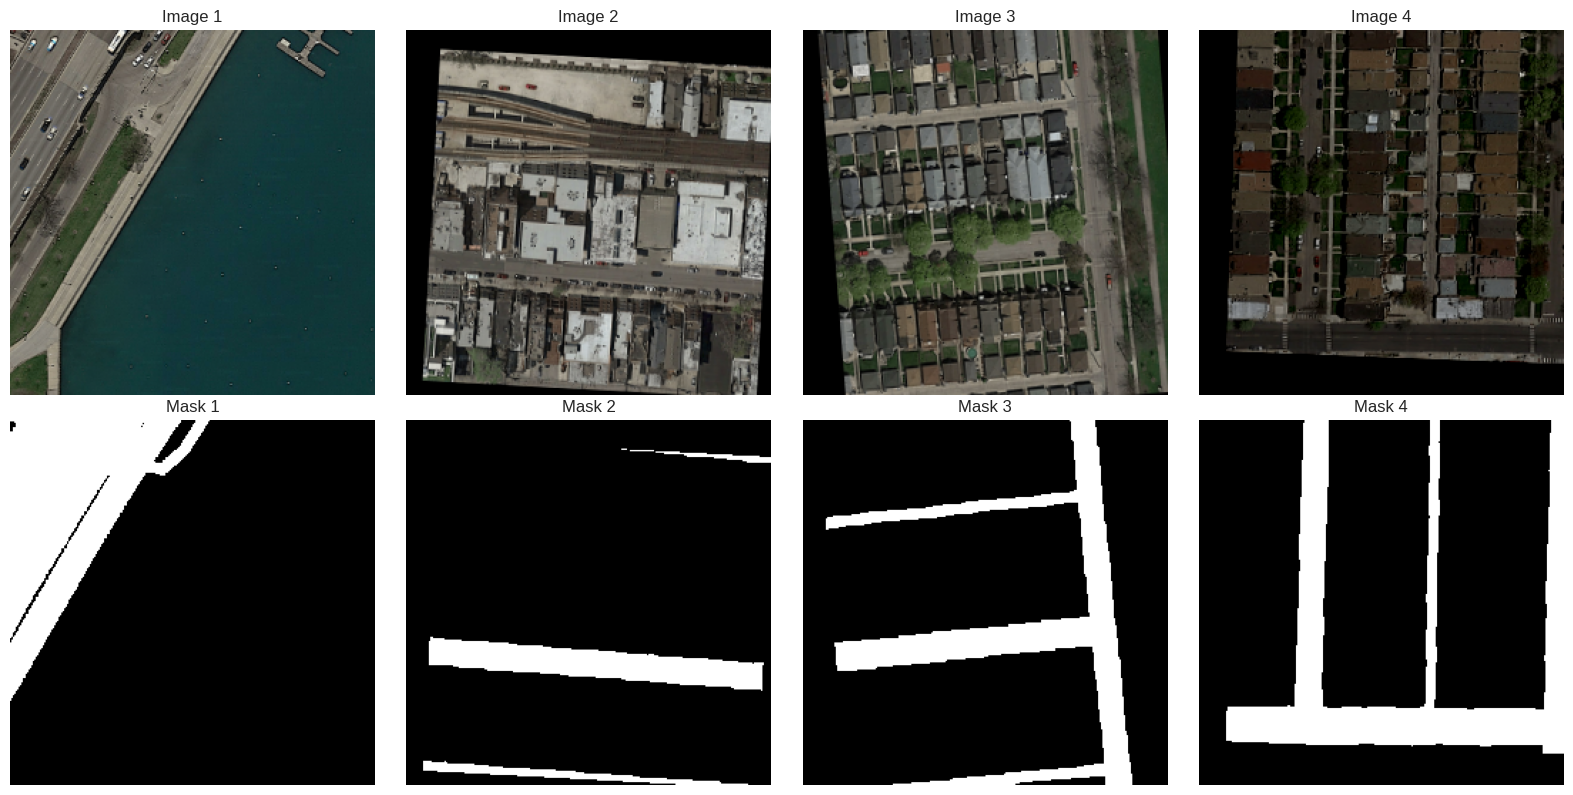

In [22]:
# Create dataloaders
train_loader, val_loader = create_dataloaders(config)

# Visualize some samples
def visualize_samples(dataloader, num_samples=4):
    """Visualize samples from the dataloader."""
    images, masks = next(iter(dataloader))
    
    fig, axes = plt.subplots(2, num_samples, figsize=(4*num_samples, 8))
    
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    
    for i in range(num_samples):
        # Denormalize image
        img = images[i] * std + mean
        img = img.permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        
        mask = masks[i, 0].numpy()
        
        axes[0, i].imshow(img)
        axes[0, i].set_title(f'Image {i+1}')
        axes[0, i].axis('off')
        
        axes[1, i].imshow(mask, cmap='gray')
        axes[1, i].set_title(f'Mask {i+1}')
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()

visualize_samples(train_loader)

---
## 5. Loss Functions and Metrics

In [23]:
class DiceLoss(nn.Module):
    """Dice Loss for segmentation."""
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth
    
    def forward(self, pred, target):
        pred = torch.sigmoid(pred)
        pred_flat = pred.view(-1)
        target_flat = target.view(-1)
        
        intersection = (pred_flat * target_flat).sum()
        dice = (2. * intersection + self.smooth) / (
            pred_flat.sum() + target_flat.sum() + self.smooth
        )
        return 1 - dice


class BCEDiceLoss(nn.Module):
    """Combined BCE and Dice Loss."""
    def __init__(self, bce_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()
    
    def forward(self, pred, target):
        return self.bce_weight * self.bce(pred, target) + self.dice_weight * self.dice(pred, target)

In [24]:
def dice_coefficient(pred, target, threshold=0.5):
    """Calculate Dice coefficient."""
    pred = (torch.sigmoid(pred) > threshold).float()
    pred_flat = pred.view(-1)
    target_flat = target.view(-1)
    
    intersection = (pred_flat * target_flat).sum()
    return (2. * intersection + 1e-6) / (pred_flat.sum() + target_flat.sum() + 1e-6)


def iou_score(pred, target, threshold=0.5):
    """Calculate IoU (Jaccard Index)."""
    pred = (torch.sigmoid(pred) > threshold).float()
    pred_flat = pred.view(-1)
    target_flat = target.view(-1)
    
    intersection = (pred_flat * target_flat).sum()
    union = pred_flat.sum() + target_flat.sum() - intersection
    return (intersection + 1e-6) / (union + 1e-6)

---
## 6. Model Architectures

In [25]:
class DoubleConv(nn.Module):
    """Double Convolution Block: (Conv -> BN -> ReLU) x 2"""
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout) if dropout > 0 else nn.Identity(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.conv(x)

In [26]:
class UNet(nn.Module):
    """
    Standard U-Net Architecture.
    
    Reference: Ronneberger et al., "U-Net: Convolutional Networks for 
    Biomedical Image Segmentation", MICCAI 2015
    """
    def __init__(self, in_channels=3, num_classes=1, 
                 encoder_channels=[64, 128, 256, 512],
                 bottleneck_channels=1024, dropout=0.1):
        super().__init__()
        
        self.encoder_channels = encoder_channels
        
        # Encoder
        self.inc = DoubleConv(in_channels, encoder_channels[0])
        
        self.encoders = nn.ModuleList()
        for i in range(len(encoder_channels) - 1):
            self.encoders.append(nn.Sequential(
                nn.MaxPool2d(2),
                DoubleConv(encoder_channels[i], encoder_channels[i+1], dropout)
            ))
        
        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(encoder_channels[-1], bottleneck_channels, dropout)
        )
        
        # Decoder
        decoder_channels = encoder_channels[::-1]
        self.decoders = nn.ModuleList()
        self.upconvs = nn.ModuleList()
        
        # First decoder from bottleneck
        self.upconvs.append(nn.ConvTranspose2d(bottleneck_channels, decoder_channels[0], 2, stride=2))
        self.decoders.append(DoubleConv(decoder_channels[0] * 2, decoder_channels[0], dropout))
        
        for i in range(len(decoder_channels) - 1):
            self.upconvs.append(nn.ConvTranspose2d(decoder_channels[i], decoder_channels[i+1], 2, stride=2))
            self.decoders.append(DoubleConv(decoder_channels[i+1] * 2, decoder_channels[i+1], dropout))
        
        # Output
        self.outc = nn.Conv2d(encoder_channels[0], num_classes, 1)
        
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
    
    def forward(self, x):
        # Encoder
        enc_features = []
        x = self.inc(x)
        enc_features.append(x)
        
        for encoder in self.encoders:
            x = encoder(x)
            enc_features.append(x)
        
        # Bottleneck
        x = self.bottleneck(x)
        
        # Decoder
        enc_features = enc_features[::-1]
        for i, (upconv, decoder) in enumerate(zip(self.upconvs, self.decoders)):
            x = upconv(x)
            # Handle size mismatch
            if x.shape != enc_features[i].shape:
                x = F.interpolate(x, size=enc_features[i].shape[2:])
            x = torch.cat([enc_features[i], x], dim=1)
            x = decoder(x)
        
        return self.outc(x)
    
    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

In [27]:
class AttentionGate(nn.Module):
    """
    Attention Gate for focusing on relevant spatial regions.
    
    Reference: Oktay et al., "Attention U-Net: Learning Where to Look 
    for the Pancreas", MIDL 2018
    """
    def __init__(self, gate_ch, feature_ch, inter_ch=None):
        super().__init__()
        inter_ch = inter_ch or feature_ch // 2
        
        self.W_g = nn.Sequential(
            nn.Conv2d(gate_ch, inter_ch, 1, bias=True),
            nn.BatchNorm2d(inter_ch)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(feature_ch, inter_ch, 1, bias=True),
            nn.BatchNorm2d(inter_ch)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(inter_ch, 1, 1, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, x, g):
        # Upsample gate to match feature size
        g = F.interpolate(g, size=x.shape[2:], mode='bilinear', align_corners=True)
        
        g_transformed = self.W_g(g)
        x_transformed = self.W_x(x)
        
        combined = self.relu(g_transformed + x_transformed)
        attention = self.psi(combined)
        
        return x * attention

In [28]:
class AttentionUNet(nn.Module):
    """
    U-Net with Attention Gates on skip connections.
    
    The attention mechanism allows the model to focus on relevant
    spatial regions, suppressing irrelevant background features.
    """
    def __init__(self, in_channels=3, num_classes=1,
                 encoder_channels=[64, 128, 256, 512],
                 bottleneck_channels=1024, dropout=0.1):
        super().__init__()
        
        self.encoder_channels = encoder_channels
        
        # Encoder
        self.inc = DoubleConv(in_channels, encoder_channels[0])
        
        self.encoders = nn.ModuleList()
        for i in range(len(encoder_channels) - 1):
            self.encoders.append(nn.Sequential(
                nn.MaxPool2d(2),
                DoubleConv(encoder_channels[i], encoder_channels[i+1], dropout)
            ))
        
        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(encoder_channels[-1], bottleneck_channels, dropout)
        )
        
        # Decoder with Attention Gates
        decoder_channels = encoder_channels[::-1]
        self.attention_gates = nn.ModuleList()
        self.decoders = nn.ModuleList()
        self.upconvs = nn.ModuleList()
        
        # First decoder from bottleneck
        self.upconvs.append(nn.ConvTranspose2d(bottleneck_channels, decoder_channels[0], 2, stride=2))
        self.attention_gates.append(AttentionGate(decoder_channels[0], decoder_channels[0]))
        self.decoders.append(DoubleConv(decoder_channels[0] * 2, decoder_channels[0], dropout))
        
        for i in range(len(decoder_channels) - 1):
            self.upconvs.append(nn.ConvTranspose2d(decoder_channels[i], decoder_channels[i+1], 2, stride=2))
            self.attention_gates.append(AttentionGate(decoder_channels[i+1], decoder_channels[i+1]))
            self.decoders.append(DoubleConv(decoder_channels[i+1] * 2, decoder_channels[i+1], dropout))
        
        # Output
        self.outc = nn.Conv2d(encoder_channels[0], num_classes, 1)
        
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
    
    def forward(self, x):
        # Encoder
        enc_features = []
        x = self.inc(x)
        enc_features.append(x)
        
        for encoder in self.encoders:
            x = encoder(x)
            enc_features.append(x)
        
        # Bottleneck
        x = self.bottleneck(x)
        
        # Decoder with Attention
        enc_features = enc_features[::-1]
        for i, (upconv, attn, decoder) in enumerate(zip(self.upconvs, self.attention_gates, self.decoders)):
            x = upconv(x)
            # Apply attention to encoder features
            enc_feat_attended = attn(enc_features[i], x)
            # Handle size mismatch
            if x.shape != enc_feat_attended.shape:
                x = F.interpolate(x, size=enc_feat_attended.shape[2:])
            x = torch.cat([enc_feat_attended, x], dim=1)
            x = decoder(x)
        
        return self.outc(x)
    
    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

In [29]:
# Test models
print("Model Parameter Comparison")
print("=" * 50)

baseline = UNet(
    encoder_channels=config.encoder_channels,
    bottleneck_channels=config.bottleneck_channels,
    dropout=config.dropout_rate
)
attention = AttentionUNet(
    encoder_channels=config.encoder_channels,
    bottleneck_channels=config.bottleneck_channels,
    dropout=config.dropout_rate
)

print(f"Baseline U-Net:  {baseline.count_parameters():,} parameters")
print(f"Attention U-Net: {attention.count_parameters():,} parameters")
print(f"Attention overhead: {attention.count_parameters() - baseline.count_parameters():,} "
      f"({100*(attention.count_parameters()-baseline.count_parameters())/baseline.count_parameters():.1f}%)")

# Test forward pass
x = torch.randn(2, 3, 256, 256)
with torch.no_grad():
    y1 = baseline(x)
    y2 = attention(x)
print(f"\nInput shape:  {x.shape}")
print(f"Output shape: {y1.shape}")

Model Parameter Comparison
Baseline U-Net:  31,037,633 parameters
Attention U-Net: 31,389,165 parameters
Attention overhead: 351,532 (1.1%)

Input shape:  torch.Size([2, 3, 256, 256])
Output shape: torch.Size([2, 1, 256, 256])


---
## 7. Training Functions

In [30]:
def train_one_epoch(model, dataloader, criterion, optimizer, device, scaler=None):
    """Train for one epoch."""
    model.train()
    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0
    
    pbar = tqdm(dataloader, desc='Training', leave=False)
    for images, masks in pbar:
        images = images.to(device)
        masks = masks.to(device)
        
        optimizer.zero_grad()
        
        # Mixed precision
        if scaler:
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, masks)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
        
        running_loss += loss.item()
        with torch.no_grad():
            running_dice += dice_coefficient(outputs, masks).item()
            running_iou += iou_score(outputs, masks).item()
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    n = len(dataloader)
    return running_loss/n, running_dice/n, running_iou/n


@torch.no_grad()
def validate(model, dataloader, criterion, device):
    """Validate the model."""
    model.eval()
    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0
    
    for images, masks in tqdm(dataloader, desc='Validation', leave=False):
        images = images.to(device)
        masks = masks.to(device)
        
        outputs = model(images)
        loss = criterion(outputs, masks)
        
        running_loss += loss.item()
        running_dice += dice_coefficient(outputs, masks).item()
        running_iou += iou_score(outputs, masks).item()
    
    n = len(dataloader)
    return running_loss/n, running_dice/n, running_iou/n

In [31]:
def train_model(model, train_loader, val_loader, config, model_name='model'):
    """
    Full training loop.
    
    Returns:
        Trained model and training history
    """
    device = torch.device(config.device)
    model = model.to(device)
    
    criterion = BCEDiceLoss()
    optimizer = optim.Adam(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=5, factor=0.5)
    scaler = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None
    
    history = {
        'train_loss': [], 'train_dice': [], 'train_iou': [],
        'val_loss': [], 'val_dice': [], 'val_iou': [], 'lr': []
    }
    
    best_dice = 0.0
    best_model_state = None
    patience_counter = 0
    
    print(f"\n{'='*60}")
    print(f"Training {model_name}")
    print(f"{'='*60}")
    
    for epoch in range(1, config.num_epochs + 1):
        print(f"\nEpoch {epoch}/{config.num_epochs}")
        
        # Train
        train_loss, train_dice, train_iou = train_one_epoch(
            model, train_loader, criterion, optimizer, device, scaler
        )
        
        # Validate
        val_loss, val_dice, val_iou = validate(model, val_loader, criterion, device)
        
        # Update scheduler
        scheduler.step(val_dice)
        current_lr = optimizer.param_groups[0]['lr']
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_dice'].append(train_dice)
        history['train_iou'].append(train_iou)
        history['val_loss'].append(val_loss)
        history['val_dice'].append(val_dice)
        history['val_iou'].append(val_iou)
        history['lr'].append(current_lr)
        
        # Print progress
        print(f"  Train - Loss: {train_loss:.4f} | Dice: {train_dice:.4f} | IoU: {train_iou:.4f}")
        print(f"  Val   - Loss: {val_loss:.4f} | Dice: {val_dice:.4f} | IoU: {val_iou:.4f}")
        
        # Save best model
        if val_dice > best_dice:
            best_dice = val_dice
            best_model_state = model.state_dict().copy()
            patience_counter = 0
            print(f"  ★ New best model! (Dice: {best_dice:.4f})")
        else:
            patience_counter += 1
        
        # Early stopping
        if patience_counter >= config.early_stopping_patience:
            print(f"\nEarly stopping at epoch {epoch}")
            break
    
    # Load best model
    if best_model_state:
        model.load_state_dict(best_model_state)
    
    print(f"\nTraining complete! Best validation Dice: {best_dice:.4f}")
    
    return model, history, best_dice

---
## 8. Train Models

In [32]:
# Train Baseline U-Net
baseline_model = UNet(
    encoder_channels=config.encoder_channels,
    bottleneck_channels=config.bottleneck_channels,
    dropout=config.dropout_rate
)

baseline_model, baseline_history, baseline_best_dice = train_model(
    baseline_model, train_loader, val_loader, config, 
    model_name='Baseline U-Net'
)


Training Baseline U-Net

Epoch 1/50


/tmp/ipython-input-4190791836.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None


Training:   0%|          | 0/10 [00:00<?, ?it/s]

/tmp/ipython-input-3392436025.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Validation:   0%|          | 0/3 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/3 [00:00<?, ?it/s]

  Train - Loss: 0.2179 | Dice: 0.8043 | IoU: 0.6743
  Val   - Loss: 0.1958 | Dice: 0.8218 | IoU: 0.6990

Epoch 50/50


Training:   0%|          | 0/10 [00:00<?, ?it/s]

Validation:   0%|          | 0/3 [00:00<?, ?it/s]

  Train - Loss: 0.2170 | Dice: 0.8024 | IoU: 0.6710
  Val   - Loss: 0.1875 | Dice: 0.8336 | IoU: 0.7154

Training complete! Best validation Dice: 0.8502


In [33]:
# Train Attention U-Net
attention_model = AttentionUNet(
    encoder_channels=config.encoder_channels,
    bottleneck_channels=config.bottleneck_channels,
    dropout=config.dropout_rate
)

attention_model, attention_history, attention_best_dice = train_model(
    attention_model, train_loader, val_loader, config,
    model_name='Attention U-Net'
)


Training Attention U-Net

Epoch 1/50


/tmp/ipython-input-4190791836.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None


Training:   0%|          | 0/10 [00:00<?, ?it/s]

/tmp/ipython-input-3392436025.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Validation:   0%|          | 0/3 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/3 [00:00<?, ?it/s]

  Train - Loss: 0.2070 | Dice: 0.8125 | IoU: 0.6857
  Val   - Loss: 0.1844 | Dice: 0.8288 | IoU: 0.7083

Epoch 50/50


Training:   0%|          | 0/10 [00:00<?, ?it/s]

Validation:   0%|          | 0/3 [00:00<?, ?it/s]

  Train - Loss: 0.2036 | Dice: 0.8185 | IoU: 0.6940
  Val   - Loss: 0.1780 | Dice: 0.8376 | IoU: 0.7217
  ★ New best model! (Dice: 0.8376)

Training complete! Best validation Dice: 0.8376


---
## 9. Results and Visualization

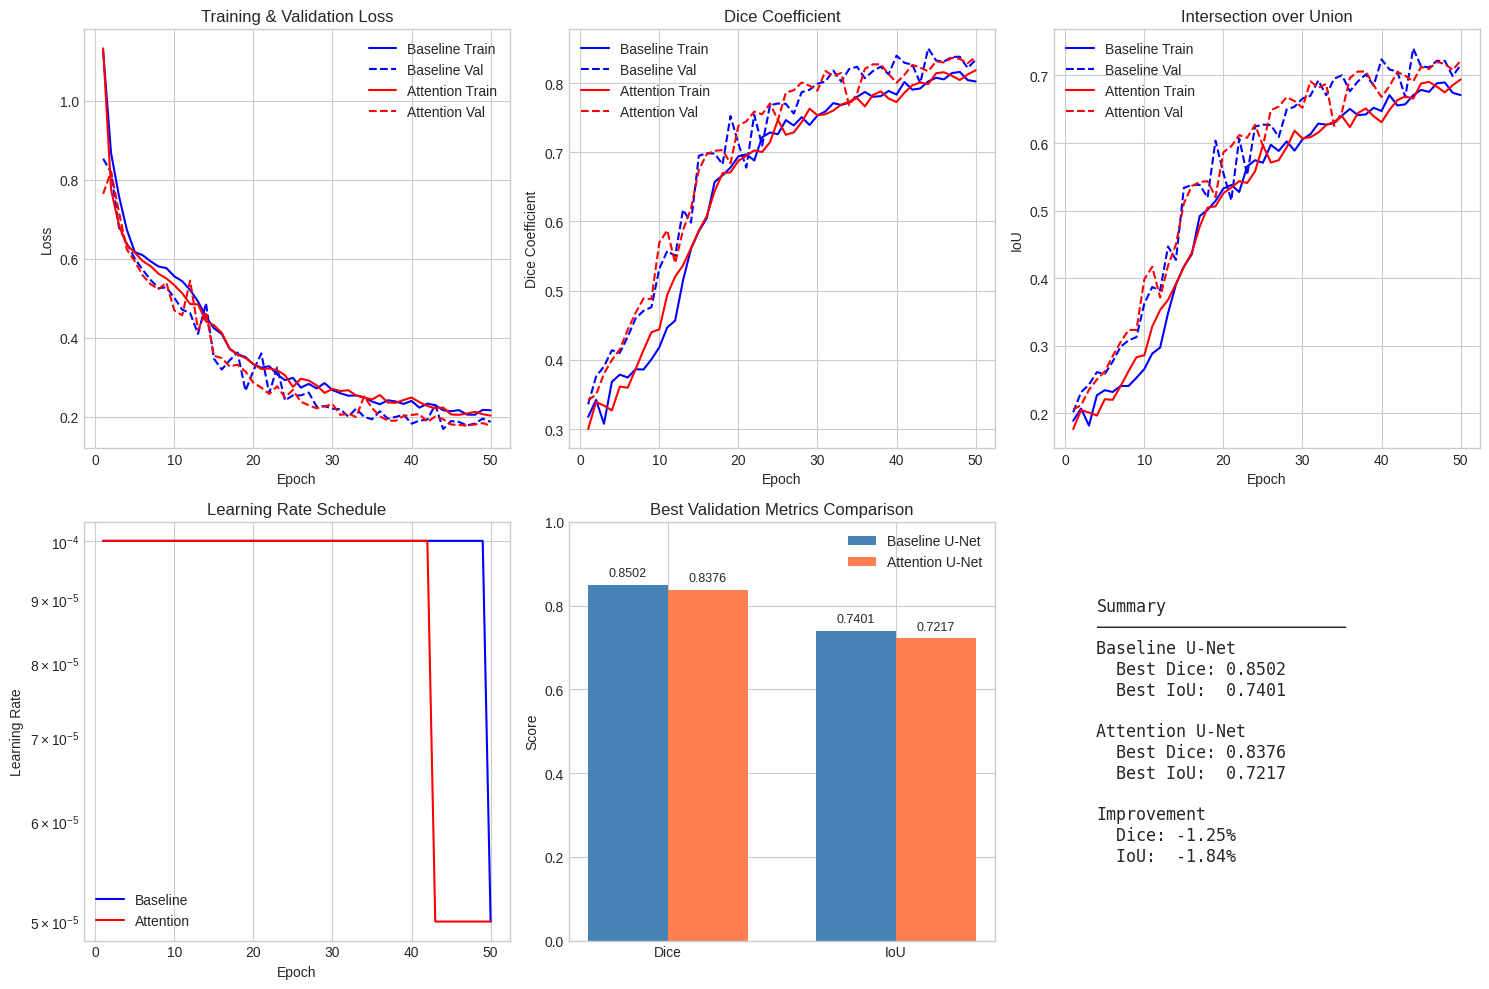

In [34]:
def plot_training_history(baseline_history, attention_history):
    """Plot training curves for both models."""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    epochs_b = range(1, len(baseline_history['train_loss']) + 1)
    epochs_a = range(1, len(attention_history['train_loss']) + 1)
    
    # Loss
    axes[0, 0].plot(epochs_b, baseline_history['train_loss'], 'b-', label='Baseline Train')
    axes[0, 0].plot(epochs_b, baseline_history['val_loss'], 'b--', label='Baseline Val')
    axes[0, 0].plot(epochs_a, attention_history['train_loss'], 'r-', label='Attention Train')
    axes[0, 0].plot(epochs_a, attention_history['val_loss'], 'r--', label='Attention Val')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Training & Validation Loss')
    axes[0, 0].legend()
    
    # Dice
    axes[0, 1].plot(epochs_b, baseline_history['train_dice'], 'b-', label='Baseline Train')
    axes[0, 1].plot(epochs_b, baseline_history['val_dice'], 'b--', label='Baseline Val')
    axes[0, 1].plot(epochs_a, attention_history['train_dice'], 'r-', label='Attention Train')
    axes[0, 1].plot(epochs_a, attention_history['val_dice'], 'r--', label='Attention Val')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Dice Coefficient')
    axes[0, 1].set_title('Dice Coefficient')
    axes[0, 1].legend()
    
    # IoU
    axes[0, 2].plot(epochs_b, baseline_history['train_iou'], 'b-', label='Baseline Train')
    axes[0, 2].plot(epochs_b, baseline_history['val_iou'], 'b--', label='Baseline Val')
    axes[0, 2].plot(epochs_a, attention_history['train_iou'], 'r-', label='Attention Train')
    axes[0, 2].plot(epochs_a, attention_history['val_iou'], 'r--', label='Attention Val')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('IoU')
    axes[0, 2].set_title('Intersection over Union')
    axes[0, 2].legend()
    
    # Learning Rate
    axes[1, 0].plot(epochs_b, baseline_history['lr'], 'b-', label='Baseline')
    axes[1, 0].plot(epochs_a, attention_history['lr'], 'r-', label='Attention')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Learning Rate')
    axes[1, 0].set_title('Learning Rate Schedule')
    axes[1, 0].legend()
    axes[1, 0].set_yscale('log')
    
    # Validation comparison bar chart
    metrics = ['Dice', 'IoU']
    baseline_vals = [max(baseline_history['val_dice']), max(baseline_history['val_iou'])]
    attention_vals = [max(attention_history['val_dice']), max(attention_history['val_iou'])]
    
    x = np.arange(len(metrics))
    width = 0.35
    
    axes[1, 1].bar(x - width/2, baseline_vals, width, label='Baseline U-Net', color='steelblue')
    axes[1, 1].bar(x + width/2, attention_vals, width, label='Attention U-Net', color='coral')
    axes[1, 1].set_ylabel('Score')
    axes[1, 1].set_title('Best Validation Metrics Comparison')
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(metrics)
    axes[1, 1].legend()
    axes[1, 1].set_ylim([0, 1])
    
    # Add values on bars
    for i, (b, a) in enumerate(zip(baseline_vals, attention_vals)):
        axes[1, 1].text(i - width/2, b + 0.02, f'{b:.4f}', ha='center', fontsize=9)
        axes[1, 1].text(i + width/2, a + 0.02, f'{a:.4f}', ha='center', fontsize=9)
    
    # Hide last subplot
    axes[1, 2].axis('off')
    
    # Add summary text
    summary = f"""Summary
─────────────────────────
Baseline U-Net
  Best Dice: {max(baseline_history['val_dice']):.4f}
  Best IoU:  {max(baseline_history['val_iou']):.4f}

Attention U-Net
  Best Dice: {max(attention_history['val_dice']):.4f}
  Best IoU:  {max(attention_history['val_iou']):.4f}

Improvement
  Dice: {(max(attention_history['val_dice'])-max(baseline_history['val_dice']))*100:+.2f}%
  IoU:  {(max(attention_history['val_iou'])-max(baseline_history['val_iou']))*100:+.2f}%"""
    
    axes[1, 2].text(0.1, 0.5, summary, fontsize=12, family='monospace',
                    verticalalignment='center', transform=axes[1, 2].transAxes)
    
    plt.tight_layout()
    plt.savefig('training_results.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_training_history(baseline_history, attention_history)

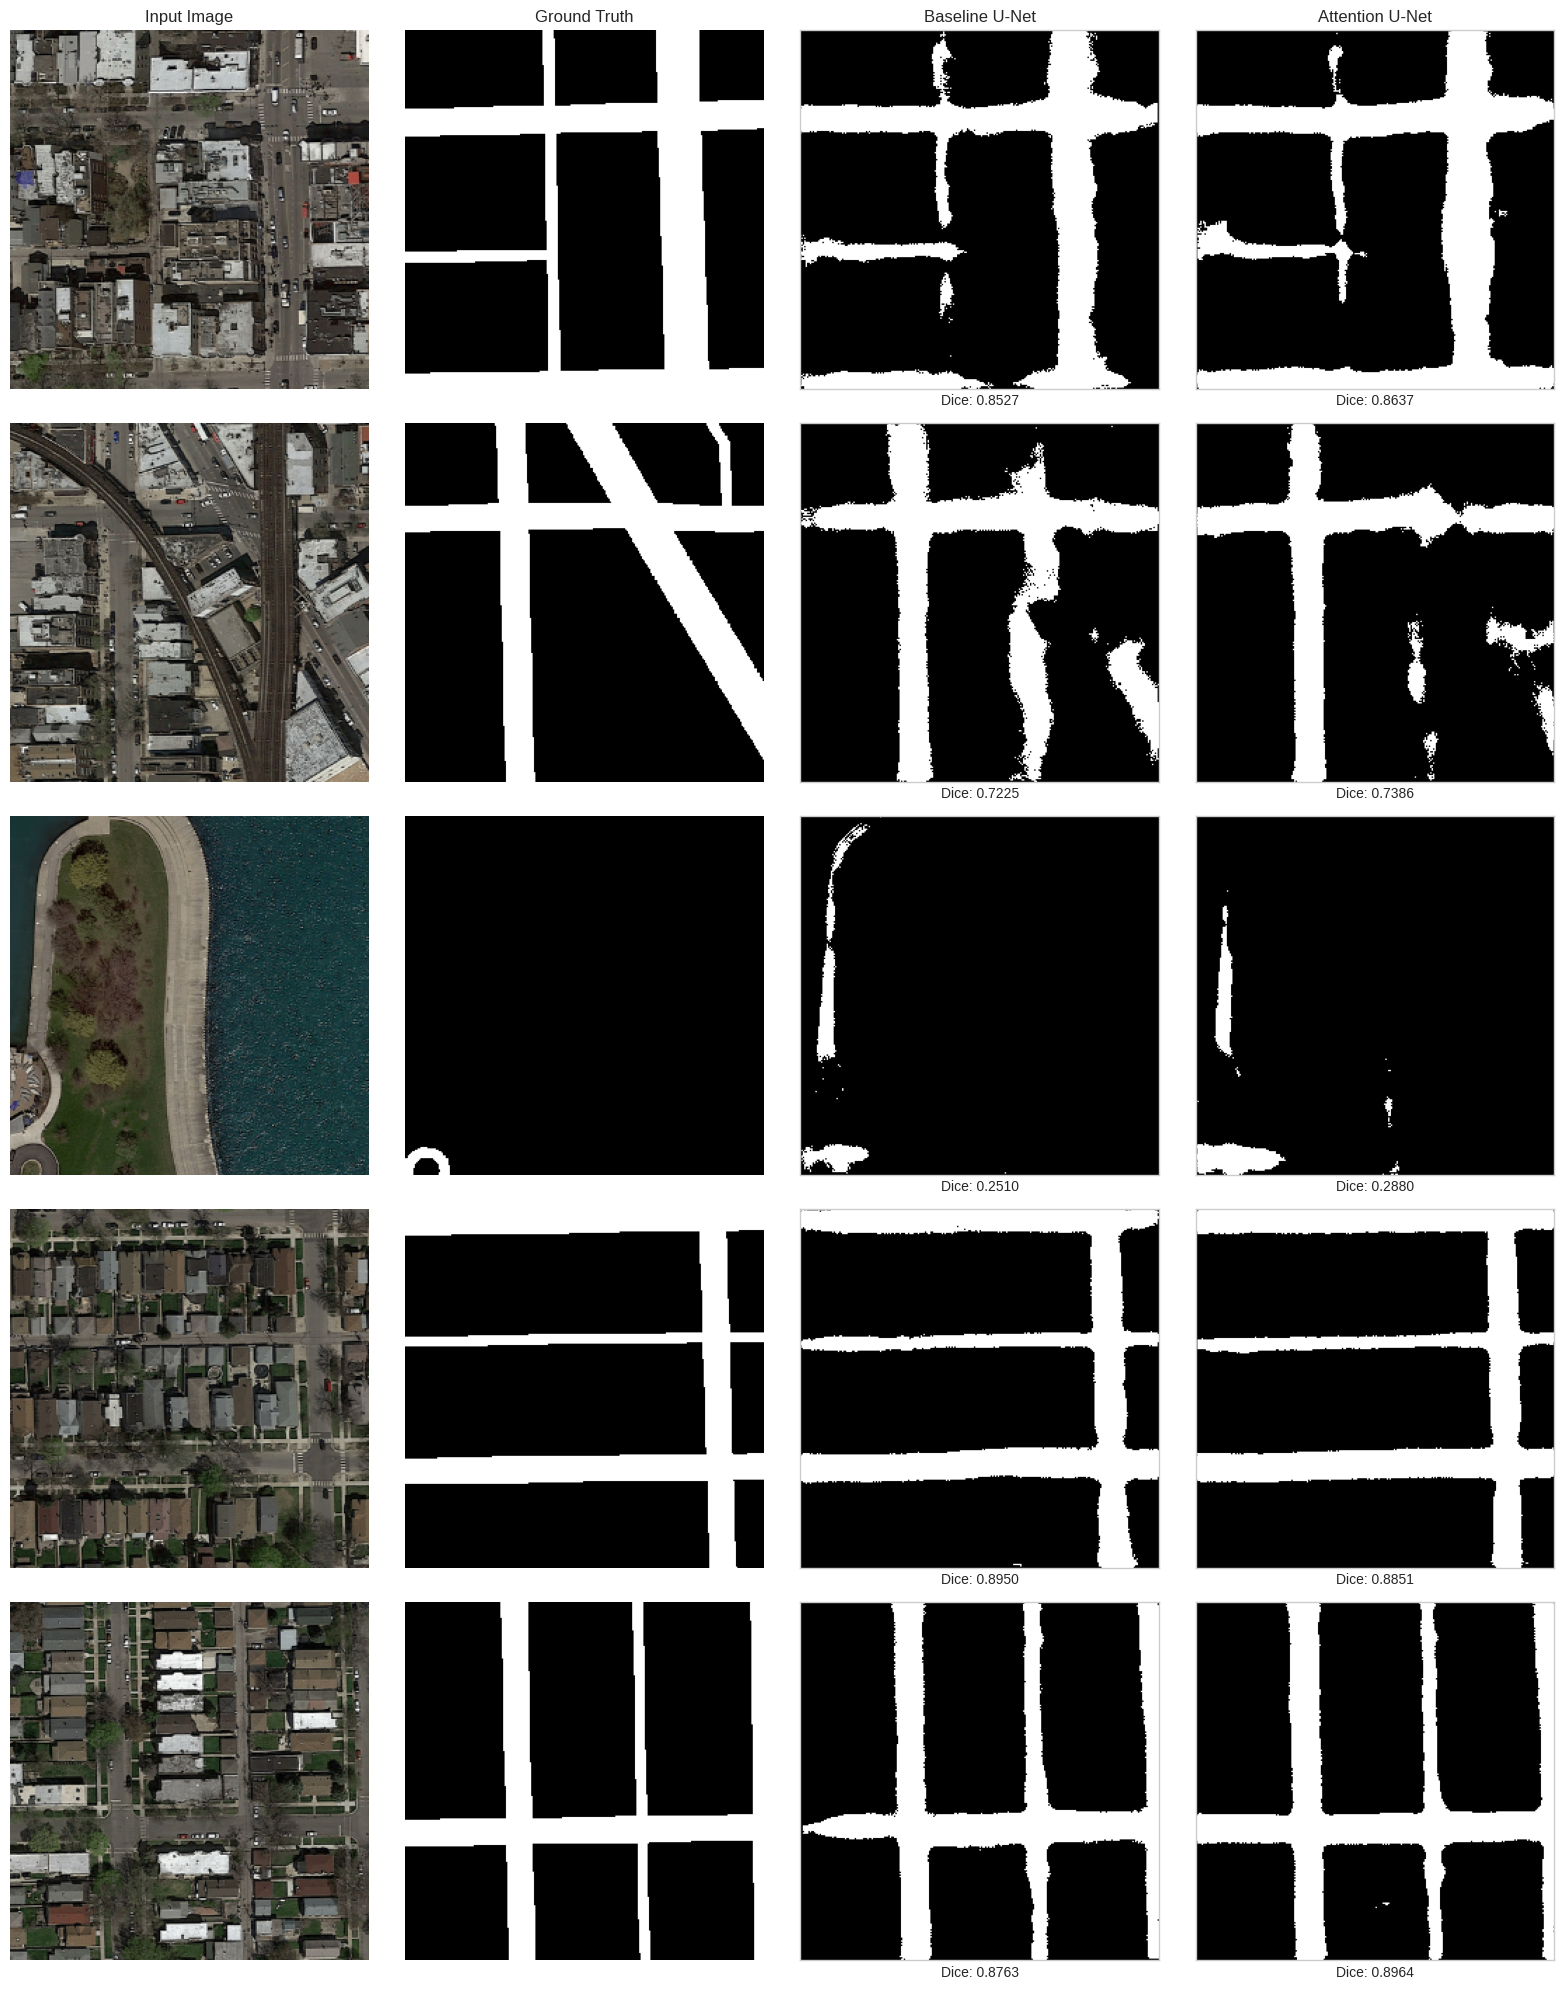

In [35]:
@torch.no_grad()
def visualize_predictions(models, dataloader, device, num_samples=5):
    """Visualize predictions from both models."""
    for model in models.values():
        model.eval()
    
    images, masks = next(iter(dataloader))
    images = images[:num_samples].to(device)
    masks = masks[:num_samples]
    
    predictions = {}
    for name, model in models.items():
        pred = torch.sigmoid(model(images)).cpu()
        predictions[name] = (pred > 0.5).float()
    
    # Denormalize
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
    images_denorm = (images.cpu() * std + mean).clamp(0, 1)
    
    # Plot
    num_cols = 2 + len(models)
    fig, axes = plt.subplots(num_samples, num_cols, figsize=(4*num_cols, 4*num_samples))
    
    col_titles = ['Input Image', 'Ground Truth'] + list(models.keys())
    
    for i in range(num_samples):
        # Image
        axes[i, 0].imshow(images_denorm[i].permute(1, 2, 0).numpy())
        if i == 0:
            axes[i, 0].set_title(col_titles[0], fontsize=12)
        axes[i, 0].axis('off')
        
        # Ground truth
        axes[i, 1].imshow(masks[i, 0].numpy(), cmap='gray')
        if i == 0:
            axes[i, 1].set_title(col_titles[1], fontsize=12)
        axes[i, 1].axis('off')
        
        # Predictions
        for j, (name, pred) in enumerate(predictions.items()):
            dice = dice_coefficient(pred[i:i+1], masks[i:i+1]).item()
            axes[i, 2+j].imshow(pred[i, 0].numpy(), cmap='gray')
            if i == 0:
                axes[i, 2+j].set_title(col_titles[2+j], fontsize=12)
            axes[i, 2+j].set_xlabel(f'Dice: {dice:.4f}', fontsize=10)
            axes[i, 2+j].set_xticks([])
            axes[i, 2+j].set_yticks([])
    
    plt.tight_layout()
    plt.savefig('predictions_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

models = {
    'Baseline U-Net': baseline_model,
    'Attention U-Net': attention_model
}
visualize_predictions(models, val_loader, config.device)

---
## 10. Results Summary

In [36]:
# Create results summary table
print("\n" + "="*70)
print("EXPERIMENT RESULTS SUMMARY")
print("="*70)
print(f"\nDataset: Satellite Road Segmentation")
print(f"Training images: {len(train_loader.dataset)}")
print(f"Validation images: {len(val_loader.dataset)}")
print(f"Image size: {config.image_size}")
print(f"\n{'-'*70}")
print(f"{'Model':<20} {'Parameters':>15} {'Best Dice':>12} {'Best IoU':>12}")
print(f"{'-'*70}")

results = {
    'Baseline U-Net': {
        'params': baseline_model.count_parameters(),
        'dice': max(baseline_history['val_dice']),
        'iou': max(baseline_history['val_iou'])
    },
    'Attention U-Net': {
        'params': attention_model.count_parameters(),
        'dice': max(attention_history['val_dice']),
        'iou': max(attention_history['val_iou'])
    }
}

for name, metrics in results.items():
    print(f"{name:<20} {metrics['params']:>15,} {metrics['dice']:>12.4f} {metrics['iou']:>12.4f}")

print(f"{'-'*70}")
improvement_dice = (results['Attention U-Net']['dice'] - results['Baseline U-Net']['dice']) * 100
improvement_iou = (results['Attention U-Net']['iou'] - results['Baseline U-Net']['iou']) * 100
print(f"\nAttention U-Net Improvement:")
print(f"  Dice: {improvement_dice:+.2f}%")
print(f"  IoU:  {improvement_iou:+.2f}%")
print("="*70)


EXPERIMENT RESULTS SUMMARY

Dataset: Satellite Road Segmentation
Training images: 80
Validation images: 20
Image size: (256, 256)

----------------------------------------------------------------------
Model                     Parameters    Best Dice     Best IoU
----------------------------------------------------------------------
Baseline U-Net            31,037,633       0.8502       0.7401
Attention U-Net           31,389,165       0.8376       0.7217
----------------------------------------------------------------------

Attention U-Net Improvement:
  Dice: -1.25%
  IoU:  -1.84%


---
## 11. Save Models and Results

In [37]:
# Save models
torch.save(baseline_model.state_dict(), 'baseline_unet.pt')
torch.save(attention_model.state_dict(), 'attention_unet.pt')
print("Models saved!")

# Save results
results_data = {
    'config': {
        'image_size': config.image_size,
        'batch_size': config.batch_size,
        'learning_rate': config.learning_rate,
        'num_epochs': config.num_epochs
    },
    'baseline': {
        'parameters': baseline_model.count_parameters(),
        'best_dice': max(baseline_history['val_dice']),
        'best_iou': max(baseline_history['val_iou']),
        'history': baseline_history
    },
    'attention': {
        'parameters': attention_model.count_parameters(),
        'best_dice': max(attention_history['val_dice']),
        'best_iou': max(attention_history['val_iou']),
        'history': attention_history
    }
}

with open('results.json', 'w') as f:
    json.dump(results_data, f, indent=2)
print("Results saved to results.json!")

Models saved!
Results saved to results.json!


In [ ]:
# Download files (in Colab)
from google.colab import files

# Uncomment to download
# files.download('baseline_unet.pt')
# files.download('attention_unet.pt')
# files.download('results.json')
# files.download('training_results.png')
# files.download('predictions_comparison.png')

---
## References

1. Wang J., Ruhaiyem N.I.R., Fu P. (2025). "A Comprehensive Review of U-Net and Its Variants: Advances and Applications in Medical Image Segmentation." *IET Image Processing*. [arXiv:2502.06895](https://arxiv.org/abs/2502.06895)

2. Ronneberger O., Fischer P., Brox T. (2015). "U-Net: Convolutional Networks for Biomedical Image Segmentation." *MICCAI 2015*. [arXiv:1505.04597](https://arxiv.org/abs/1505.04597)

3. Oktay O., et al. (2018). "Attention U-Net: Learning Where to Look for the Pancreas." *MIDL 2018*. [arXiv:1804.03999](https://arxiv.org/abs/1804.03999)

---
## 12. Experiment with Generated Images (Extended Dataset)

Now let's train both models using the **full dataset** including Pix2Pix generated images.
This will give us more training data and may help the Attention U-Net learn better attention patterns.

In [38]:
# Create new config with generated images enabled
@dataclass
class ConfigWithGenerated:
    """Configuration with generated images included."""
    data_root: str = DATA_ROOT
    image_size: Tuple[int, int] = (256, 256)
    use_generated: bool = True  # ← NOW USING GENERATED IMAGES
    val_split: float = 0.15  # Use 15% for validation (more data now)
    
    encoder_channels: List[int] = field(default_factory=lambda: [64, 128, 256, 512])
    bottleneck_channels: int = 1024
    dropout_rate: float = 0.1
    
    batch_size: int = 16  # Can use larger batch with more data
    num_epochs: int = 50
    learning_rate: float = 1e-4
    weight_decay: float = 1e-5
    early_stopping_patience: int = 10
    
    device: str = 'cuda' if torch.cuda.is_available() else 'cpu'
    seed: int = 42

config_gen = ConfigWithGenerated()
print(f"Extended Dataset Configuration:")
print(f"  Use generated images: {config_gen.use_generated}")
print(f"  Batch size: {config_gen.batch_size}")
print(f"  Validation split: {config_gen.val_split}")

Extended Dataset Configuration:
  Use generated images: True
  Batch size: 16
  Validation split: 0.15


In [39]:
# Create dataloaders with generated images
print("Creating dataloaders with GENERATED images included...")
train_loader_gen, val_loader_gen = create_dataloaders(config_gen)

print(f"\nDataset size comparison:")
print(f"  Original only: 80 train, 20 val")
print(f"  With generated: {len(train_loader_gen.dataset)} train, {len(val_loader_gen.dataset)} val")

Creating dataloaders with GENERATED images included...
Collected 1103 image-mask pairs
Train: 938 images, Val: 165 images

Dataset size comparison:
  Original only: 80 train, 20 val
  With generated: 938 train, 165 val


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [40]:
# Train Baseline U-Net with generated images
print("Training Baseline U-Net with extended dataset...")
baseline_model_gen = UNet(
    encoder_channels=config_gen.encoder_channels,
    bottleneck_channels=config_gen.bottleneck_channels,
    dropout=config_gen.dropout_rate
)

baseline_model_gen, baseline_history_gen, baseline_best_dice_gen = train_model(
    baseline_model_gen, train_loader_gen, val_loader_gen, config_gen,
    model_name='Baseline U-Net (with Generated)'
)

Training Baseline U-Net with extended dataset...

Training Baseline U-Net (with Generated)

Epoch 1/50


/tmp/ipython-input-4190791836.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None


Training:   0%|          | 0/59 [00:00<?, ?it/s]

/tmp/ipython-input-3392436025.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Validation:   0%|          | 0/11 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/11 [00:00<?, ?it/s]

  Train - Loss: 0.0714 | Dice: 0.9365 | IoU: 0.8807
  Val   - Loss: 0.0516 | Dice: 0.9557 | IoU: 0.9153
  ★ New best model! (Dice: 0.9557)

Epoch 50/50


Training:   0%|          | 0/59 [00:00<?, ?it/s]

Validation:   0%|          | 0/11 [00:00<?, ?it/s]

  Train - Loss: 0.0747 | Dice: 0.9334 | IoU: 0.8753
  Val   - Loss: 0.0555 | Dice: 0.9529 | IoU: 0.9102

Training complete! Best validation Dice: 0.9557


In [41]:
# Train Attention U-Net with generated images
print("Training Attention U-Net with extended dataset...")
attention_model_gen = AttentionUNet(
    encoder_channels=config_gen.encoder_channels,
    bottleneck_channels=config_gen.bottleneck_channels,
    dropout=config_gen.dropout_rate
)

attention_model_gen, attention_history_gen, attention_best_dice_gen = train_model(
    attention_model_gen, train_loader_gen, val_loader_gen, config_gen,
    model_name='Attention U-Net (with Generated)'
)

Training Attention U-Net with extended dataset...

Training Attention U-Net (with Generated)

Epoch 1/50


/tmp/ipython-input-4190791836.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None


Training:   0%|          | 0/59 [00:00<?, ?it/s]

/tmp/ipython-input-3392436025.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Validation:   0%|          | 0/11 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/11 [00:00<?, ?it/s]

  Train - Loss: 0.0685 | Dice: 0.9390 | IoU: 0.8852
  Val   - Loss: 0.0483 | Dice: 0.9599 | IoU: 0.9230
  ★ New best model! (Dice: 0.9599)

Epoch 50/50


Training:   0%|          | 0/59 [00:00<?, ?it/s]

Validation:   0%|          | 0/11 [00:00<?, ?it/s]

  Train - Loss: 0.0701 | Dice: 0.9371 | IoU: 0.8819
  Val   - Loss: 0.0510 | Dice: 0.9573 | IoU: 0.9182

Training complete! Best validation Dice: 0.9599


In [42]:
# Compare ALL experiments
print("\n" + "="*80)
print("COMPLETE EXPERIMENT COMPARISON")
print("="*80)

print(f"\n{'Dataset':<25} {'Model':<25} {'Dice':>10} {'IoU':>10}")
print("-"*80)

# Original dataset results
print(f"{'Original (100 images)':<25} {'Baseline U-Net':<25} {max(baseline_history['val_dice']):>10.4f} {max(baseline_history['val_iou']):>10.4f}")
print(f"{'':<25} {'Attention U-Net':<25} {max(attention_history['val_dice']):>10.4f} {max(attention_history['val_iou']):>10.4f}")

print("-"*80)

# Extended dataset results
print(f"{'Extended (with Gen.)':<25} {'Baseline U-Net':<25} {max(baseline_history_gen['val_dice']):>10.4f} {max(baseline_history_gen['val_iou']):>10.4f}")
print(f"{'':<25} {'Attention U-Net':<25} {max(attention_history_gen['val_dice']):>10.4f} {max(attention_history_gen['val_iou']):>10.4f}")

print("="*80)

# Calculate improvements
orig_baseline_dice = max(baseline_history['val_dice'])
orig_attention_dice = max(attention_history['val_dice'])
gen_baseline_dice = max(baseline_history_gen['val_dice'])
gen_attention_dice = max(attention_history_gen['val_dice'])

print(f"\nKey Findings:")
print(f"  1. Original Dataset - Attention vs Baseline: {(orig_attention_dice - orig_baseline_dice)*100:+.2f}%")
print(f"  2. Extended Dataset - Attention vs Baseline: {(gen_attention_dice - gen_baseline_dice)*100:+.2f}%")
print(f"  3. Baseline improvement with more data: {(gen_baseline_dice - orig_baseline_dice)*100:+.2f}%")
print(f"  4. Attention improvement with more data: {(gen_attention_dice - orig_attention_dice)*100:+.2f}%")


COMPLETE EXPERIMENT COMPARISON

Dataset                   Model                           Dice        IoU
--------------------------------------------------------------------------------
Original (100 images)     Baseline U-Net                0.8502     0.7401
                          Attention U-Net               0.8376     0.7217
--------------------------------------------------------------------------------
Extended (with Gen.)      Baseline U-Net                0.9557     0.9153
                          Attention U-Net               0.9599     0.9230

Key Findings:
  1. Original Dataset - Attention vs Baseline: -1.25%
  2. Extended Dataset - Attention vs Baseline: +0.42%
  3. Baseline improvement with more data: +10.55%
  4. Attention improvement with more data: +12.23%


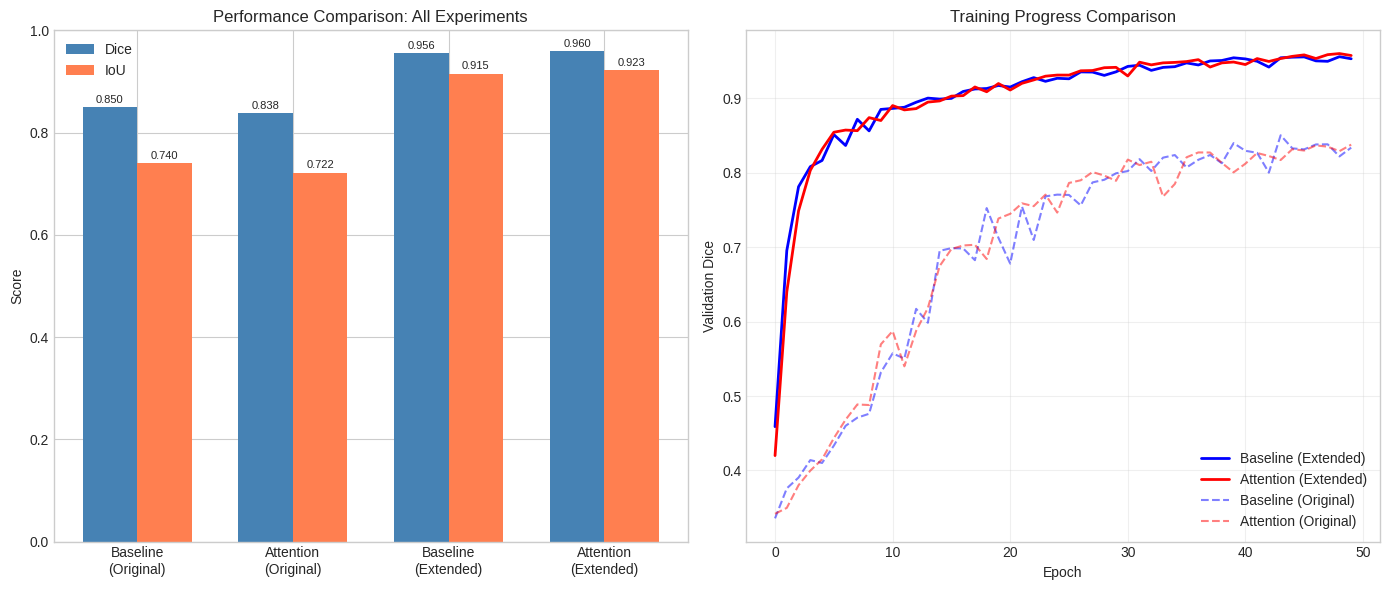


Saved: complete_comparison.png


In [43]:
# Visualization: Compare all 4 experiments
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart comparison
models = ['Baseline\n(Original)', 'Attention\n(Original)', 'Baseline\n(Extended)', 'Attention\n(Extended)']
dice_scores = [
    max(baseline_history['val_dice']),
    max(attention_history['val_dice']),
    max(baseline_history_gen['val_dice']),
    max(attention_history_gen['val_dice'])
]
iou_scores = [
    max(baseline_history['val_iou']),
    max(attention_history['val_iou']),
    max(baseline_history_gen['val_iou']),
    max(attention_history_gen['val_iou'])
]

x = np.arange(len(models))
width = 0.35

bars1 = axes[0].bar(x - width/2, dice_scores, width, label='Dice', color='steelblue')
bars2 = axes[0].bar(x + width/2, iou_scores, width, label='IoU', color='coral')

axes[0].set_ylabel('Score')
axes[0].set_title('Performance Comparison: All Experiments')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].legend()
axes[0].set_ylim([0, 1])

# Add value labels
for bar in bars1:
    height = bar.get_height()
    axes[0].annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                     xytext=(0, 3), textcoords="offset points", ha='center', fontsize=8)
for bar in bars2:
    height = bar.get_height()
    axes[0].annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                     xytext=(0, 3), textcoords="offset points", ha='center', fontsize=8)

# Training curves comparison
axes[1].plot(baseline_history_gen['val_dice'], 'b-', label='Baseline (Extended)', linewidth=2)
axes[1].plot(attention_history_gen['val_dice'], 'r-', label='Attention (Extended)', linewidth=2)
axes[1].plot(baseline_history['val_dice'], 'b--', alpha=0.5, label='Baseline (Original)')
axes[1].plot(attention_history['val_dice'], 'r--', alpha=0.5, label='Attention (Original)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Dice')
axes[1].set_title('Training Progress Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('complete_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: complete_comparison.png")

In [44]:
# Generate LaTeX-ready table for paper
print("\n" + "="*80)
print("TABLE FOR PAPER (Copy this to your LaTeX document)")
print("="*80)

latex_table = """
\\begin{table}[h]
\\centering
\\caption{Experimental Results: Comparison of U-Net Variants on Satellite Road Segmentation}
\\label{tab:results}
\\begin{tabular}{llccc}
\\hline
\\textbf{Dataset} & \\textbf{Model} & \\textbf{Parameters} & \\textbf{Dice} & \\textbf{IoU} \\\\
\\hline
"""

latex_table += f"Original (100 images) & Baseline U-Net & 31.04M & {max(baseline_history['val_dice']):.4f} & {max(baseline_history['val_iou']):.4f} \\\\\n"
latex_table += f" & Attention U-Net & 31.39M & {max(attention_history['val_dice']):.4f} & {max(attention_history['val_iou']):.4f} \\\\\n"
latex_table += "\\hline\n"
latex_table += f"Extended (with Gen.) & Baseline U-Net & 31.04M & {max(baseline_history_gen['val_dice']):.4f} & {max(baseline_history_gen['val_iou']):.4f} \\\\\n"
latex_table += f" & Attention U-Net & 31.39M & {max(attention_history_gen['val_dice']):.4f} & {max(attention_history_gen['val_iou']):.4f} \\\\\n"

latex_table += """\\hline
\\end{tabular}
\\end{table}
"""

print(latex_table)

# Save all results
all_results = {
    'original_dataset': {
        'baseline': {
            'best_dice': max(baseline_history['val_dice']),
            'best_iou': max(baseline_history['val_iou']),
            'history': baseline_history
        },
        'attention': {
            'best_dice': max(attention_history['val_dice']),
            'best_iou': max(attention_history['val_iou']),
            'history': attention_history
        }
    },
    'extended_dataset': {
        'baseline': {
            'best_dice': max(baseline_history_gen['val_dice']),
            'best_iou': max(baseline_history_gen['val_iou']),
            'history': baseline_history_gen
        },
        'attention': {
            'best_dice': max(attention_history_gen['val_dice']),
            'best_iou': max(attention_history_gen['val_iou']),
            'history': attention_history_gen
        }
    }
}

with open('all_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)
print("\nAll results saved to: all_results.json")


TABLE FOR PAPER (Copy this to your LaTeX document)

\begin{table}[h]
\centering
\caption{Experimental Results: Comparison of U-Net Variants on Satellite Road Segmentation}
\label{tab:results}
\begin{tabular}{llccc}
\hline
\textbf{Dataset} & \textbf{Model} & \textbf{Parameters} & \textbf{Dice} & \textbf{IoU} \\
\hline
Original (100 images) & Baseline U-Net & 31.04M & 0.8502 & 0.7401 \\
 & Attention U-Net & 31.39M & 0.8376 & 0.7217 \\
\hline
Extended (with Gen.) & Baseline U-Net & 31.04M & 0.9557 & 0.9153 \\
 & Attention U-Net & 31.39M & 0.9599 & 0.9230 \\
\hline
\end{tabular}
\end{table}


All results saved to: all_results.json


---
## 13. Predictions on Test Images

Generate predictions on the 50 test images using both trained models.
These test images have no ground truth, so we'll compare the model outputs visually.

In [ ]:
# Load test images
def load_test_images(data_root, image_size=(256, 256)):
    """Load all test images from test_set_images folder."""
    test_dir = Path(data_root) / 'test_set_images'
    
    test_images = []
    test_names = []
    
    transform = get_transforms(image_size, is_train=False)
    
    # Test images are in nested folders: test_1/test_1.png
    for test_folder in sorted(test_dir.iterdir()):
        if test_folder.is_dir() and test_folder.name.startswith('test_'):
            img_path = test_folder / f"{test_folder.name}.png"
            if img_path.exists():
                # Load and transform image
                image = np.array(Image.open(img_path).convert('RGB'))
                transformed = transform(image=image, mask=np.zeros_like(image[:,:,0]))
                test_images.append(transformed['image'])
                test_names.append(test_folder.name)
    
    print(f"Loaded {len(test_images)} test images")
    return torch.stack(test_images), test_names

test_images, test_names = load_test_images(DATA_ROOT, config_gen.image_size)
print(f"Test images shape: {test_images.shape}")

In [ ]:
@torch.no_grad()
def generate_predictions(models, images, device, batch_size=8):
    """Generate predictions for all test images using multiple models."""
    all_predictions = {name: [] for name in models.keys()}
    
    for model in models.values():
        model.eval()
    
    # Process in batches
    num_images = images.shape[0]
    for i in tqdm(range(0, num_images, batch_size), desc="Generating predictions"):
        batch = images[i:i+batch_size].to(device)
        
        for name, model in models.items():
            pred = torch.sigmoid(model(batch))
            all_predictions[name].append(pred.cpu())
    
    # Concatenate all predictions
    for name in all_predictions:
        all_predictions[name] = torch.cat(all_predictions[name], dim=0)
    
    return all_predictions

# Generate predictions with both models (trained on extended dataset)
models_to_test = {
    'Baseline U-Net': baseline_model_gen,
    'Attention U-Net': attention_model_gen
}

predictions = generate_predictions(models_to_test, test_images, config_gen.device)
print(f"Generated predictions for {len(test_names)} test images")

In [ ]:
# Visualize test predictions
def visualize_test_predictions(images, predictions, names, num_samples=8, threshold=0.5):
    """Visualize predictions on test images."""
    num_samples = min(num_samples, len(names))
    
    # Denormalize images
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
    images_denorm = (images * std + mean).clamp(0, 1)
    
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4*num_samples))
    
    for i in range(num_samples):
        # Original image
        img = images_denorm[i].permute(1, 2, 0).numpy()
        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f'{names[i]}' if i == 0 else names[i])
        if i == 0:
            axes[i, 0].set_title('Input Image', fontsize=12, fontweight='bold')
        axes[i, 0].axis('off')
        axes[i, 0].set_ylabel(names[i], fontsize=10)
        
        # Baseline prediction
        baseline_pred = (predictions['Baseline U-Net'][i, 0] > threshold).float().numpy()
        axes[i, 1].imshow(baseline_pred, cmap='gray')
        if i == 0:
            axes[i, 1].set_title('Baseline U-Net', fontsize=12, fontweight='bold')
        axes[i, 1].axis('off')
        
        # Attention prediction
        attention_pred = (predictions['Attention U-Net'][i, 0] > threshold).float().numpy()
        axes[i, 2].imshow(attention_pred, cmap='gray')
        if i == 0:
            axes[i, 2].set_title('Attention U-Net', fontsize=12, fontweight='bold')
        axes[i, 2].axis('off')
        
        # Difference (where models disagree)
        diff = np.abs(attention_pred - baseline_pred)
        axes[i, 3].imshow(diff, cmap='hot')
        if i == 0:
            axes[i, 3].set_title('Difference', fontsize=12, fontweight='bold')
        axes[i, 3].axis('off')
    
    plt.tight_layout()
    plt.savefig('test_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: test_predictions.png")

# Visualize first 8 test images
visualize_test_predictions(test_images, predictions, test_names, num_samples=8)

In [ ]:
# Create overlay visualizations (predictions overlaid on original images)
def create_overlay_visualization(images, predictions, names, num_samples=6, threshold=0.5):
    """Create overlay of predictions on original images."""
    num_samples = min(num_samples, len(names))
    
    # Denormalize
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
    images_denorm = (images * std + mean).clamp(0, 1)
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5*num_samples))
    
    for i in range(num_samples):
        img = images_denorm[i].permute(1, 2, 0).numpy()
        
        # Original
        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f'{names[i]}' if i > 0 else 'Original Image', fontsize=11)
        axes[i, 0].axis('off')
        
        # Baseline overlay
        baseline_mask = (predictions['Baseline U-Net'][i, 0] > threshold).float().numpy()
        overlay_baseline = img.copy()
        overlay_baseline[baseline_mask > 0.5] = overlay_baseline[baseline_mask > 0.5] * 0.5 + np.array([1, 0.3, 0]) * 0.5
        axes[i, 1].imshow(overlay_baseline)
        axes[i, 1].set_title('Baseline U-Net Overlay' if i == 0 else '', fontsize=11)
        axes[i, 1].axis('off')
        
        # Attention overlay
        attention_mask = (predictions['Attention U-Net'][i, 0] > threshold).float().numpy()
        overlay_attention = img.copy()
        overlay_attention[attention_mask > 0.5] = overlay_attention[attention_mask > 0.5] * 0.5 + np.array([0, 0.7, 1]) * 0.5
        axes[i, 2].imshow(overlay_attention)
        axes[i, 2].set_title('Attention U-Net Overlay' if i == 0 else '', fontsize=11)
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig('test_overlays.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: test_overlays.png")

create_overlay_visualization(test_images, predictions, test_names, num_samples=6)

In [ ]:
# Save all test predictions
import os

def save_all_predictions(predictions, names, output_dir='test_predictions', threshold=0.5):
    """Save all test predictions as images."""
    os.makedirs(output_dir, exist_ok=True)
    
    for model_name, preds in predictions.items():
        model_dir = os.path.join(output_dir, model_name.replace(' ', '_'))
        os.makedirs(model_dir, exist_ok=True)
        
        for i, name in enumerate(names):
            mask = (preds[i, 0] > threshold).float().numpy() * 255
            mask_img = Image.fromarray(mask.astype(np.uint8))
            mask_img.save(os.path.join(model_dir, f'{name}_pred.png'))
    
    print(f"Saved {len(names)} predictions for each model to '{output_dir}/'")

save_all_predictions(predictions, test_names)

# List saved files
print("\nSaved prediction folders:")
for folder in os.listdir('test_predictions'):
    num_files = len(os.listdir(f'test_predictions/{folder}'))
    print(f"  {folder}/: {num_files} images")

In [ ]:
# Analyze prediction statistics
def analyze_predictions(predictions, names, threshold=0.5):
    """Analyze and compare predictions from different models."""
    print("="*70)
    print("TEST PREDICTIONS ANALYSIS")
    print("="*70)
    
    baseline_preds = (predictions['Baseline U-Net'] > threshold).float()
    attention_preds = (predictions['Attention U-Net'] > threshold).float()
    
    # Calculate road coverage (percentage of pixels predicted as road)
    baseline_coverage = baseline_preds.mean(dim=(1,2,3)) * 100
    attention_coverage = attention_preds.mean(dim=(1,2,3)) * 100
    
    print(f"\nRoad Coverage Statistics (% of image predicted as road):")
    print(f"  {'Model':<20} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
    print(f"  {'-'*60}")
    print(f"  {'Baseline U-Net':<20} {baseline_coverage.mean():>10.2f}% {baseline_coverage.std():>10.2f}% {baseline_coverage.min():>10.2f}% {baseline_coverage.max():>10.2f}%")
    print(f"  {'Attention U-Net':<20} {attention_coverage.mean():>10.2f}% {attention_coverage.std():>10.2f}% {attention_coverage.min():>10.2f}% {attention_coverage.max():>10.2f}%")
    
    # Calculate agreement between models
    agreement = (baseline_preds == attention_preds).float().mean() * 100
    print(f"\nModel Agreement: {agreement:.2f}% of pixels have same prediction")
    
    # Per-image analysis
    print(f"\nPer-image differences (top 5 most different):")
    per_image_diff = (baseline_preds != attention_preds).float().mean(dim=(1,2,3)) * 100
    top_diff_indices = torch.argsort(per_image_diff, descending=True)[:5]
    
    for idx in top_diff_indices:
        print(f"  {names[idx]}: {per_image_diff[idx]:.2f}% pixels differ")
    
    print("="*70)

analyze_predictions(predictions, test_names)